# Subreddits relevance investigation

In this notebook we want to understand what is a relevant subreddit and how to identify them. To do so, we will use the snapshot from 12/2014.

In [97]:
!pip install duckdb matplotlib

In [98]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()

In [ ]:
con.execute("""
SELECT COUNT(*)
FROM read_parquet('../storage/2024-12/subreddits.parquet')
""").df()

# 330_273

,count_star()
0,330273


In [ ]:
con.execute("""
SELECT
  percentile_cont(0.50) WITHIN GROUP (ORDER BY interaction_count) AS p50,
  percentile_cont(0.75) WITHIN GROUP (ORDER BY interaction_count) AS p75,
  percentile_cont(0.90) WITHIN GROUP (ORDER BY interaction_count) AS p90,
  percentile_cont(0.95) WITHIN GROUP (ORDER BY interaction_count) AS p95,
  percentile_cont(0.99) WITHIN GROUP (ORDER BY interaction_count) AS p99,
  AVG(interaction_count) AS average
FROM read_parquet('../storage/2024-12/subreddits.parquet')
""").df()

,p50,p75,p90,p95,p99,average
0,7.0,54.0,591.0,2406.4,19325.4,967.418857


## Why?

The identification of relevant subreddits is a necessary step before constructing and analyzing subreddits networks. Reddit contains thousands of thousands of communities (330k) with highly heterogeneous activity levels (average of 900 interactions per subreddit, but median of 7), resulting in networks that are computationally expensive to process and difficult to interpret. Moreover, many subreddits contribute little to the overall structure of user interactions, introducing noise and increasing the complexity of subsequent analyses.

Therefore, rather than considering all available subreddits, we aim to identify a subset of communities that preserves the most relevant structural information while reducing computational costs. This process is known as nodes sampling [1], where the objective is to retain the nodes that contribute most significantly to the graph.

In [ ]:
users_count = con.execute("""
SELECT COUNT(DISTINCT author_hash)
FROM read_parquet('../storage/2024-12/users/*.parquet')
""").fetchone()[0]

print(f"Total users {users_count:_}")

Total users 18_477_137


In [ ]:
interactions_sum = con.execute("""
SELECT SUM(interaction_count)
FROM read_parquet('../storage/2024-12/subreddits.parquet')
""").fetchone()[0]

print(f"Total interactions {interactions_sum:_}")

Total interactions 319_512_328


In [ ]:
subreddits_with_users_df = con.execute("""
SELECT
  subreddit_id,
  SUM(interactions_count) AS interactions,
  COUNT(DISTINCT author_hash) AS users
FROM read_parquet('../storage/2024-12/users/*.parquet')
GROUP BY subreddit_id
""").df()

subreddits_with_users_df

,subreddit_id,interactions,users
0,t5_2x2oy,38071.0,24149
1,t5_2qkqs,46577.0,18954
2,t5_52ltzk,500.0,220
3,t5_3948y,51348.0,29405
4,t5_2r9vp,96425.0,29240
...,...,...,...
330268,t5_6qxkg9,1.0,1
330269,t5_d2sqt1,1.0,1
330270,t5_8mikpx,1.0,1
330271,t5_5y32q7,10.0,1


In [104]:
top_k_df = con.execute("""
SELECT *
FROM subreddits_with_users_df
ORDER BY interactions DESC
""").df()

top_k_df

,subreddit_id,interactions,users
0,t5_2qh1i,2861677.0,650647
1,t5_446kys,1446044.0,325323
2,t5_2qmg3,1220049.0,96139
3,t5_2qm9d,1128117.0,70046
4,t5_4uoy2u,921030.0,307211
...,...,...,...
330268,t5_bi5ucb,1.0,1
330269,t5_5s82f3,1.0,1
330270,t5_d5rr0h,1.0,1
330271,t5_d5kf2t,1.0,1


In [ ]:
# Top k where k is a number from 0 to 100
def get_top_k_analysis(k):
    percentil = 1 - (k / 100)
    threshold = subreddits_with_users_df["interactions"].quantile(percentil)

    top_k_percent = subreddits_with_users_df[
        subreddits_with_users_df["interactions"] >= threshold
    ]

    print(f"The threshold of the top {k}% subreddits by interaction is {int(threshold):_} interactions per subreddit")

    top_k_sum = con.execute("""
    SELECT SUM(interactions)
    FROM top_k_percent
    """).fetchone()[0]

    print(f"The top {len(top_k_percent):_} subreddits ({k}%) contain {int(top_k_sum):_} interactions") 
    print(f"This represents ~{((top_k_sum / interactions_sum) * 100):.2f}% of the total interactions")

    top_k_users = con.execute("""
    SELECT COUNT(DISTINCT u.author_hash)
    FROM read_parquet('../storage/2024-12/users/*.parquet') u
    INNER JOIN top_k_percent t ON t.subreddit_id = u.subreddit_id
    """).fetchone()[0]

    print(f"The top {len(top_k_percent):_} subreddits ({k}%) contain interactions from {top_k_users:_} users")
    print(f"This represents ~{((top_k_users / users_count) * 100):.2f}% of the total users")

In [106]:
get_top_k_analysis(1)

The threshold of the top 1% subreddits by interaction is 19_325 interactions per subreddit
The top 3_303 subreddits (1%) contain 196_528_992 interactions
This represents ~61.51% of the total interactions
The top 3_303 subreddits (1%) contain interactions from 12_815_031 users
This represents ~69.36% of the total users


In [107]:
get_top_k_analysis(5)

The threshold of the top 5% subreddits by interaction is 2_406 interactions per subreddit
The top 16_514 subreddits (5%) contain 287_289_660 interactions
This represents ~89.92% of the total interactions
The top 16_514 subreddits (5%) contain interactions from 16_791_695 users
This represents ~90.88% of the total users


In [108]:
get_top_k_analysis(6)

The threshold of the top 6% subreddits by interaction is 1_722 interactions per subreddit
The top 19_822 subreddits (6%) contain 294_040_655 interactions
This represents ~92.03% of the total interactions
The top 19_822 subreddits (6%) contain interactions from 17_102_917 users
This represents ~92.56% of the total users


In [109]:
get_top_k_analysis(10)

The threshold of the top 10% subreddits by interaction is 591 interactions per subreddit
The top 33_042 subreddits (10%) contain 307_600_287 interactions
This represents ~96.27% of the total interactions
The top 33_042 subreddits (10%) contain interactions from 17_759_687 users
This represents ~96.12% of the total users


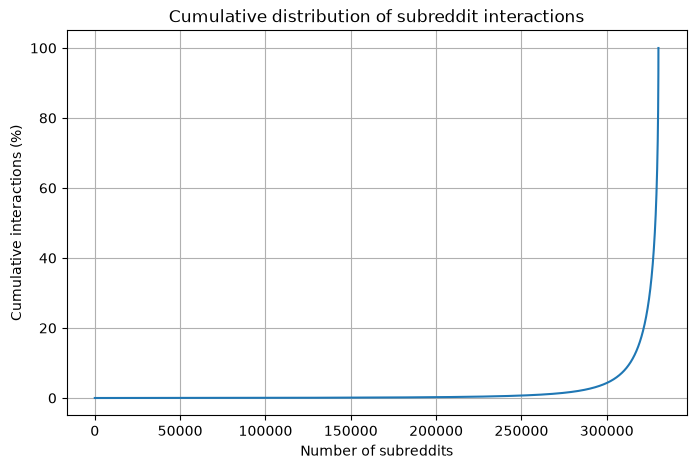

In [110]:
cumulative_interactions_df = (
    subreddits_with_users_df
    .sort_values("interactions")
    .reset_index(drop=True)
)

cum_interactions = (
    cumulative_interactions_df["interactions"]
    .cumsum()
    / cumulative_interactions_df["interactions"].sum()
)


plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_interactions_df) + 1),
    cum_interactions * 100
)
plt.xlabel("Number of subreddits")
plt.ylabel("Cumulative interactions (%)")
plt.title("Cumulative distribution of subreddit interactions")
plt.grid(True)

plt.show()

## Conclusion

Given the long-tail behavior of the interactions distributions across Reddit, we can pick the top 5% subreddits by interactions count and have 89.92% of the interactions and 90.88% of the users, preserving most of the content and the network structure, but reducing the noise and the amount of computation work

## Refereces

[1] Leskovec, J. and Faloutsos, C. 2006. Sampling from Large Graphs. In Proceedings of the 12th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '06). Association for Computing Machinery, New York, NY, USA, 631–636. https://doi.org/10.1145/1150402.1150479